# Oral Disease Image Classification — Exploratory Data Analysis

This notebook covers data loading, exploration, stratified splitting, tf.data pipeline construction, and visualization.

**Dataset:** salmansajid05/oral-diseases (6 classes)  
**Task:** Multi-class image classification

## 1. Imports & Configuration

In [2]:
# Standard library
import os
import random
from pathlib import Path

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import L2
import keras_tuner as kt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-07-17 03:36:53.640822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-17 03:36:53.691263: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-17 03:36:53.706459: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-17 03:36:53.775385: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.17.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1784259416.890722   14654 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784259417.251208   14654 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784259417.251280   14654 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

DATASET_PATH = Path("/workspaces/ODL_ASSIGNMENT/ODL/dataset")

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6
EPOCHS_BASELINE = 100      # Custom CNN improved configs
EPOCHS_PRETRAINED = 50     # Transfer learning improved configs
EPOCHS_TUNER = 30          # Keras Tuner trials
EPOCHS_REPLICA = 20        # Replica configs (matching reference)

# Set random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Create output directories
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("logs", exist_ok=True)

print("Configuration set.")

Configuration set.


## 2. Dataset Loading

In [4]:
def load_dataset(dataset_path: Path) -> pd.DataFrame:
    """Walk dataset directory, collect image paths and labels. Skips yolo folders."""
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset path does not exist: {dataset_path}")
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    records = []
    class_folders = [f for f in dataset_path.iterdir() if f.is_dir()]
    for class_folder in sorted(class_folders):
        class_name = class_folder.name
        if 'yolo' in class_name.lower():
            print(f"  [SKIPPED] {class_name}")
            continue
        class_count = 0
        for root, dirs, files in os.walk(class_folder):
            dirs[:] = [d for d in dirs if 'yolo' not in d.lower()]
            for fname in files:
                ext = os.path.splitext(fname)[1].lower()
                if ext in valid_extensions:
                    filepath = os.path.join(root, fname)
                    records.append({'filepath': filepath, 'label': class_name})
                    class_count += 1
        if class_count == 0:
            print(f"  [WARNING] No images in: {class_name}")
        else:
            print(f"  [OK] {class_name}: {class_count} images")
    if len(records) == 0:
        raise ValueError("No valid images found.")
    return pd.DataFrame(records)

# Load dataset
df = load_dataset(DATASET_PATH)
CLASS_NAMES = sorted(df['label'].unique().tolist())
LABEL_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print(f"\nTotal: {len(df)} images, Classes: {CLASS_NAMES}")

# Stratified 70/15/15 split
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=47, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=47, stratify=temp_df['label'])
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

  [OK] Calculus: 1296 images
  [SKIPPED] Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
  [OK] Data caries: 2601 images
  [OK] Gingivitis: 2349 images
  [OK] Mouth Ulcer: 2806 images
  [OK] Tooth Discoloration: 2017 images
  [OK] hypodontia: 1251 images

Total: 12320 images, Classes: ['Calculus', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia']
Train: 8624 | Val: 1848 | Test: 1848


## 3. tf.data Pipeline

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

def process_path(filepath, label):
    """Read, decode, resize, normalize image; one-hot encode label."""
    img = tf.io.read_file(filepath)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label

def build_dataset(dataframe, is_training=False):
    """Build batched, prefetched tf.data.Dataset from DataFrame."""
    filepaths = dataframe['filepath'].values
    labels = dataframe['label'].map(LABEL_TO_INDEX).values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(process_path, num_parallel_calls=AUTOTUNE)
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, is_training=True)
val_ds = build_dataset(val_df, is_training=False)
test_ds = build_dataset(test_df, is_training=False)
print("Datasets built successfully.")

I0000 00:00:1784208986.720604    2454 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784208986.720771    2454 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784208986.720821    2454 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784208987.357014    2454 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1784208987.357127    2454 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:06:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-16

Datasets built successfully.


## 4. Data Visualization

2026-07-16 13:36:30.007504: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


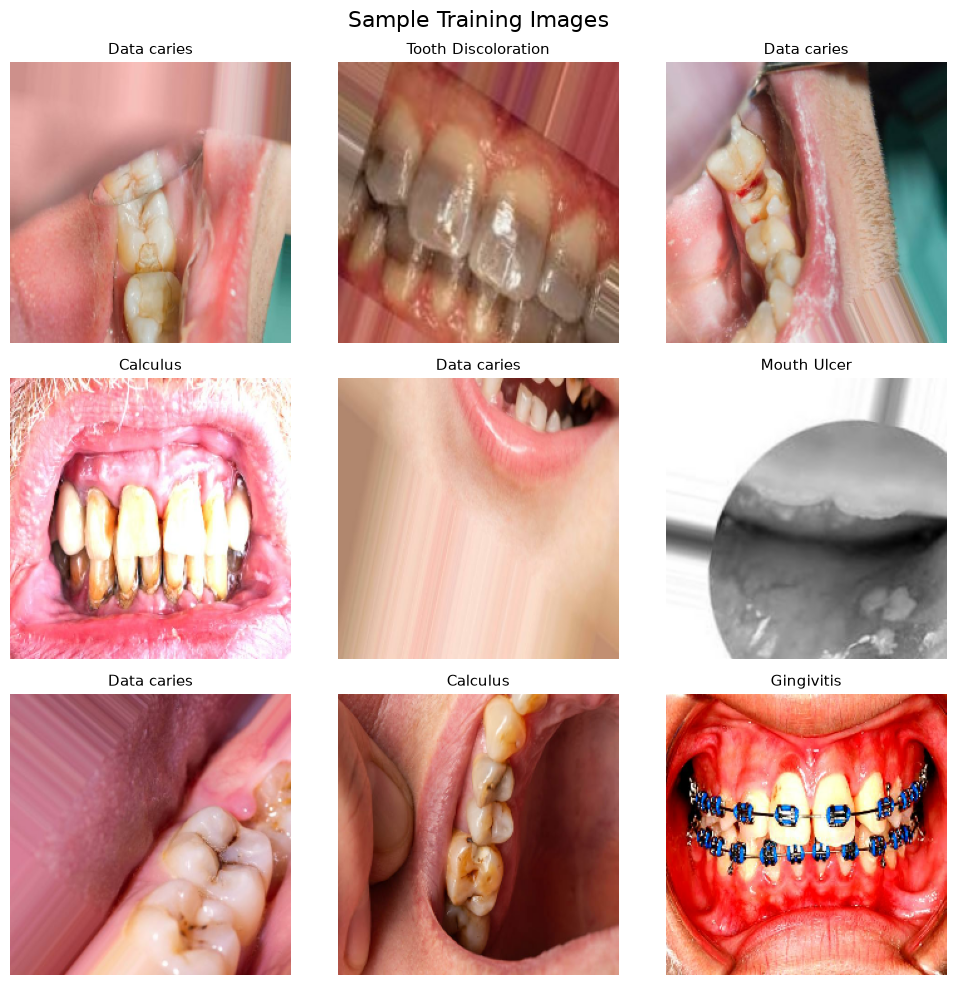

In [9]:
# --- 4.1: Sample Grid (3x3) ---
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Sample Training Images", fontsize=16)
for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].numpy())
        class_idx = tf.argmax(labels[i]).numpy()
        ax.set_title(CLASS_NAMES[class_idx], fontsize=11)
        ax.axis('off')
plt.tight_layout()
plt.show()

2026-07-16 13:36:31.969397: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


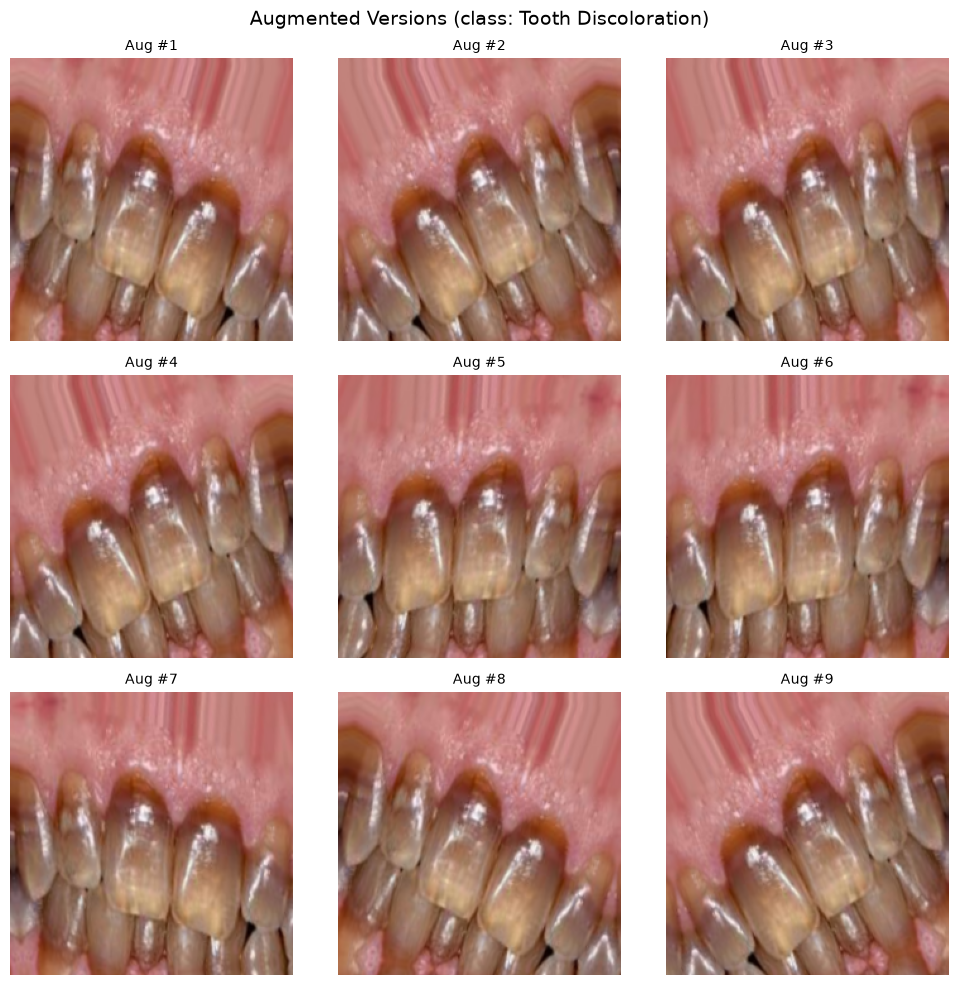

In [10]:
# --- 4.2: Augmented versions of a single image (3x3) ---
augmentation_demo = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
], name="augmentation_demo")

for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label_idx = tf.argmax(labels[0]).numpy()

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle(f"Augmented Versions (class: {CLASS_NAMES[sample_label_idx]})", fontsize=14)
for i, ax in enumerate(axes.flat):
    augmented = augmentation_demo(tf.expand_dims(sample_image, 0), training=True)
    ax.imshow(augmented[0].numpy())
    ax.set_title(f"Aug #{i+1}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

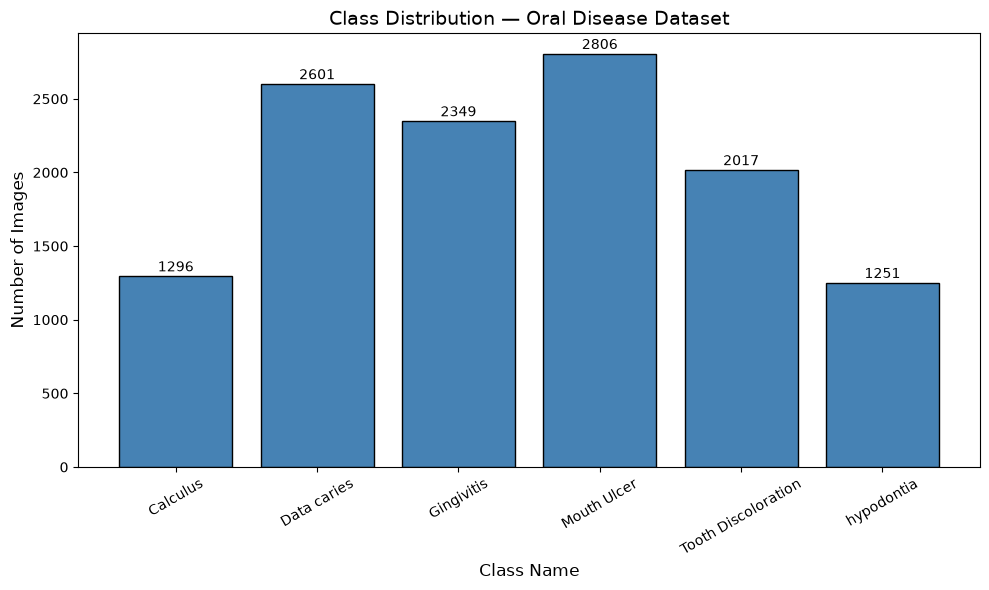

In [11]:
# --- 4.3: Class Distribution Bar Chart ---
class_counts = df['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
ax.set_xlabel("Class Name", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("Class Distribution — Oral Disease Dataset", fontsize=14)
ax.tick_params(axis='x', rotation=30)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [5]:
# --- Data Leakage Verification ---
# Prove that train, val, and test sets have ZERO overlapping file paths

train_set = set(train_df['filepath'].values)
val_set = set(val_df['filepath'].values)
test_set = set(test_df['filepath'].values)

# Check pairwise overlaps
train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set

print("=" * 50)
print("DATA LEAKAGE CHECK")
print("=" * 50)
print(f"Train-Val overlap:  {len(train_val_overlap)} images")
print(f"Train-Test overlap: {len(train_test_overlap)} images")
print(f"Val-Test overlap:   {len(val_test_overlap)} images")

assert len(train_val_overlap) == 0, "LEAKAGE: Train and Val share images!"
assert len(train_test_overlap) == 0, "LEAKAGE: Train and Test share images!"
assert len(val_test_overlap) == 0, "LEAKAGE: Val and Test share images!"

print("\n✓ No data leakage detected — all splits are completely disjoint.")
print(f"✓ Total images accounted for: {len(train_set) + len(val_set) + len(test_set)} / {len(df)}")

# Verify class distribution is preserved (stratification check)
print("\n--- Class Distribution per Split ---")
split_dist = pd.DataFrame({
    'Train (%)': (train_df['label'].value_counts(normalize=True) * 100).round(2),
    'Val (%)':   (val_df['label'].value_counts(normalize=True) * 100).round(2),
    'Test (%)':  (test_df['label'].value_counts(normalize=True) * 100).round(2),
    'Full (%)':  (df['label'].value_counts(normalize=True) * 100).round(2),
})
print(split_dist)
print("\n✓ Stratified split preserves class proportions across all splits.")


DATA LEAKAGE CHECK
Train-Val overlap:  0 images
Train-Test overlap: 0 images
Val-Test overlap:   0 images

✓ No data leakage detected — all splits are completely disjoint.
✓ Total images accounted for: 12320 / 12320

--- Class Distribution per Split ---
                     Train (%)  Val (%)  Test (%)  Full (%)
label                                                      
Mouth Ulcer              22.77    22.78     22.78     22.78
Data caries              21.12    21.10     21.10     21.11
Gingivitis               19.06    19.10     19.05     19.07
Tooth Discoloration      16.37    16.34     16.40     16.37
Calculus                 10.52    10.55     10.50     10.52
hypodontia               10.16    10.12     10.17     10.15

✓ Stratified split preserves class proportions across all splits.


## 5. Summary

- Dataset loaded with 6 classes (YOLO folder excluded)
- Stratified 70/15/15 split preserves class distribution
- tf.data pipeline is GPU-optimized with prefetching
- Augmentation (horizontal flip + rotation) demonstrated

Proceed to training notebooks (02, 03, 04) for model experiments.